In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r"C:\Users\shaikshahid.ali\OneDrive - Mu Sigma Business Solutions Pvt. Ltd\Desktop\Airline\data\cs9_airline_business_class_proper.xlsx")

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

Shape: (290, 15)

Columns:
['booking_id', 'booking_date', 'route', 'travel_class', 'booking_channel', 'traveler_type', 'ticket_price_inr', 'advance_booking_days', 'miles_redeemed', 'lounge_access_used', 'flight_load_factor_pct', 'competitor_avg_price_inr', 'wfh_policy_company', 'nps_score', 'cancelled']

Data Types:
booking_id                             str
booking_date                datetime64[us]
route                                  str
travel_class                           str
booking_channel                        str
traveler_type                          str
ticket_price_inr                     int64
advance_booking_days                 int64
miles_redeemed                       int64
lounge_access_used                   int64
flight_load_factor_pct             float64
competitor_avg_price_inr           float64
wfh_policy_company                     str
nps_score                            int64
cancelled                            int64
dtype: object

Missing Values:
bookin

,booking_id,booking_date,route,travel_class,booking_channel,traveler_type,ticket_price_inr,advance_booking_days,miles_redeemed,lounge_access_used,flight_load_factor_pct,competitor_avg_price_inr,wfh_policy_company,nps_score,cancelled
0,BK-000001,2023-11-27,BOM-BLR,Economy,Mobile App,Frequent Flyer,6168,44,24559,0,0.61,52132.0,Hybrid,8,0
1,BK-000002,2022-04-08,DEL-BLR,Economy,Website,Corporate,5211,110,5844,1,0.94,NaN,Full Office,3,0
2,BK-000003,2022-05-19,BOM-CCU,First,Mobile App,Leisure,71112,40,41519,0,0.69,71788.0,Full Office,6,0
3,BK-000004,2023-02-26,BOM-BLR,Economy,Website,Frequent Flyer,8078,7,26140,0,0.69,70806.0,Full Office,9,0
4,BK-000005,2022-03-02,BOM-BLR,Economy,Website,Corporate,5741,114,11416,1,0.72,35226.0,Full Office,2,0


In [7]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numeric_cols.tolist())

# Categorical columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("\nCategorical columns:")
print(categorical_cols.tolist())

# Cancellation distribution
print("\nCancellation counts:")
print(df["cancelled"].value_counts())

print("\nCancellation percentage:")
print(df["cancelled"].value_counts(normalize=True) * 100)

Numerical columns:
['ticket_price_inr', 'advance_booking_days', 'miles_redeemed', 'lounge_access_used', 'flight_load_factor_pct', 'competitor_avg_price_inr', 'nps_score', 'cancelled']

Categorical columns:
['booking_id', 'booking_date', 'route', 'travel_class', 'booking_channel', 'traveler_type', 'wfh_policy_company']

Cancellation counts:
cancelled
0    253
1     37
Name: count, dtype: int64

Cancellation percentage:
cancelled
0    87.241379
1    12.758621
Name: proportion, dtype: float64


In [8]:
# ==============================
# BUSINESS KPIs
# ==============================

total_bookings = len(df)
total_revenue = df["ticket_price_inr"].sum()
avg_ticket_price = df["ticket_price_inr"].mean()
cancellation_rate = df["cancelled"].mean() * 100
avg_nps = df["nps_score"].mean()
avg_load_factor = df["flight_load_factor_pct"].mean()

print("========== AIRLINE BUSINESS KPIs ==========")
print("Total Bookings       :", total_bookings)
print("Total Revenue        : ₹", round(total_revenue, 2))
print("Average Ticket Price : ₹", round(avg_ticket_price, 2))
print("Cancellation Rate    :", round(cancellation_rate, 2), "%")
print("Average NPS          :", round(avg_nps, 2))
print("Average Load Factor  :", round(avg_load_factor, 2), "%")

========== AIRLINE BUSINESS KPIs ==========
Total Bookings       : 290
Total Revenue        : ₹ 5288928
Average Ticket Price : ₹ 18237.68
Cancellation Rate    : 12.76 %
Average NPS          : 5.69
Average Load Factor  : 0.78 %


In [9]:
# Cancellation by Travel Class

cancellation_class = (
    df.groupby("travel_class")["cancelled"]
      .agg(["count", "sum", "mean"])
)

cancellation_class["cancellation_rate_%"] = (
    cancellation_class["mean"] * 100
)

cancellation_class = cancellation_class.drop(columns="mean")

display(cancellation_class.sort_values(
    "cancellation_rate_%",
    ascending=False
))

,count,sum,cancellation_rate_%
travel_class,,,
Economy,212,28,13.207547
Business,57,7,12.280702
First,21,2,9.523810


In [10]:
# Cancellation by Booking Channel

cancellation_channel = (
    df.groupby("booking_channel")["cancelled"]
      .agg(["count", "sum", "mean"])
)

cancellation_channel["cancellation_rate_%"] = (
    cancellation_channel["mean"] * 100
)

cancellation_channel = cancellation_channel.drop(columns="mean")

display(cancellation_channel.sort_values(
    "cancellation_rate_%",
    ascending=False
))

,count,sum,cancellation_rate_%
booking_channel,,,
OTA,21,4,19.047619
Travel Agent,49,9,18.367347
Corporate Portal,44,5,11.363636
Website,89,10,11.235955
Mobile App,87,9,10.344828


In [11]:
# Cancellation by Traveler Type

cancellation_traveler = (
    df.groupby("traveler_type")["cancelled"]
      .agg(["count", "sum", "mean"])
)

cancellation_traveler["cancellation_rate_%"] = (
    cancellation_traveler["mean"] * 100
)

cancellation_traveler = cancellation_traveler.drop(columns="mean")

display(cancellation_traveler.sort_values(
    "cancellation_rate_%",
    ascending=False
))

,count,sum,cancellation_rate_%
traveler_type,,,
Frequent Flyer,49,7,14.285714
Corporate,92,13,14.130435
Government,43,5,11.627907
Leisure,106,12,11.320755


In [12]:
# Average ticket price by travel class

price_analysis = (
    df.groupby("travel_class")["ticket_price_inr"]
      .agg(["count", "mean", "min", "max"])
      .sort_values("mean", ascending=False)
)

display(price_analysis)

,count,mean,min,max
travel_class,,,,
First,21,85864.476190,63171,113829
Business,57,35248.631579,24732,48736
Economy,212,6965.103774,4581,9088


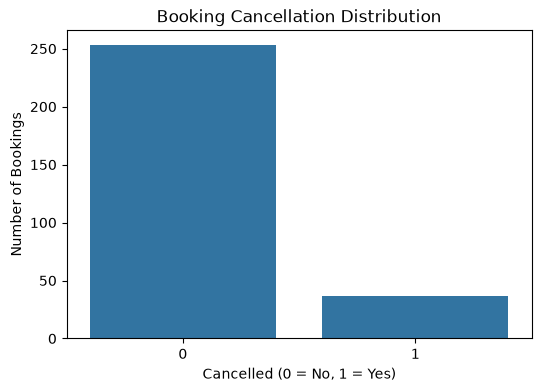

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="cancelled")

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")

plt.show()

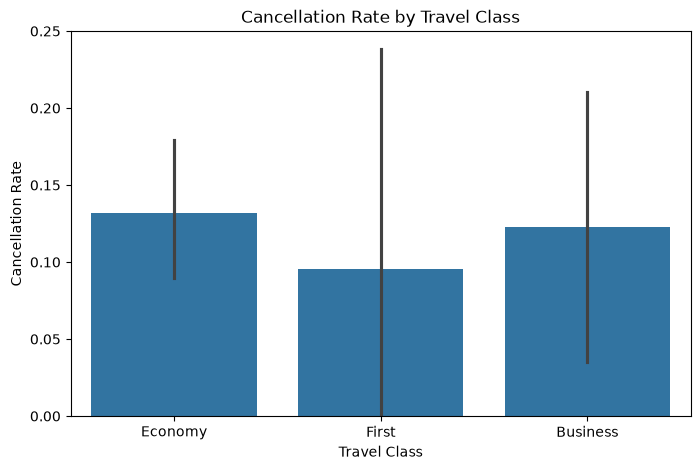

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="travel_class",
    y="cancelled"
)

plt.title("Cancellation Rate by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Cancellation Rate")

plt.show()

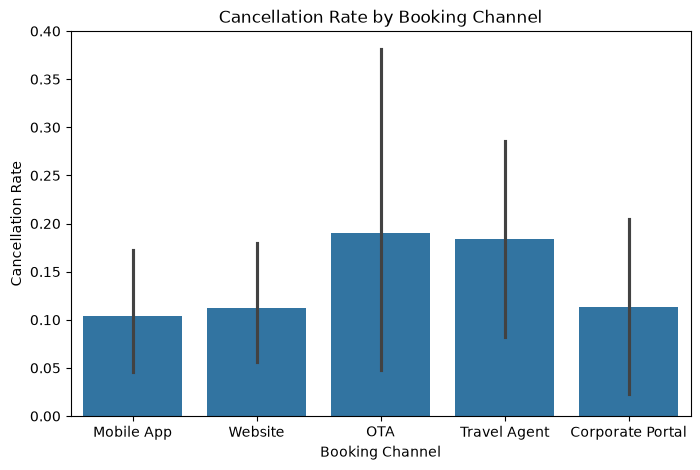

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="booking_channel",
    y="cancelled"
)

plt.title("Cancellation Rate by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Cancellation Rate")

plt.show()

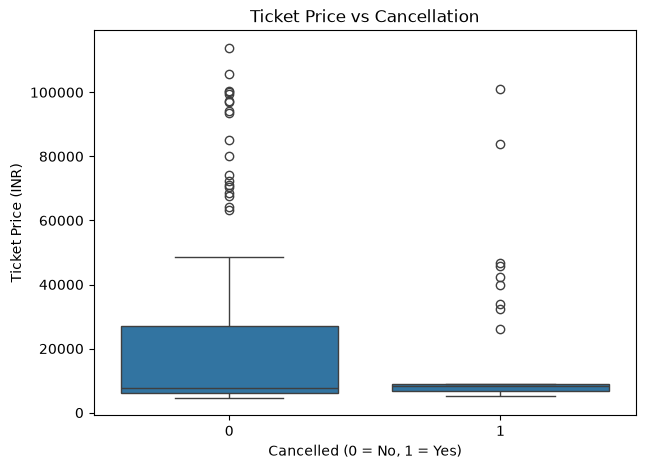

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="cancelled",
    y="ticket_price_inr"
)

plt.title("Ticket Price vs Cancellation")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Ticket Price (INR)")

plt.show()

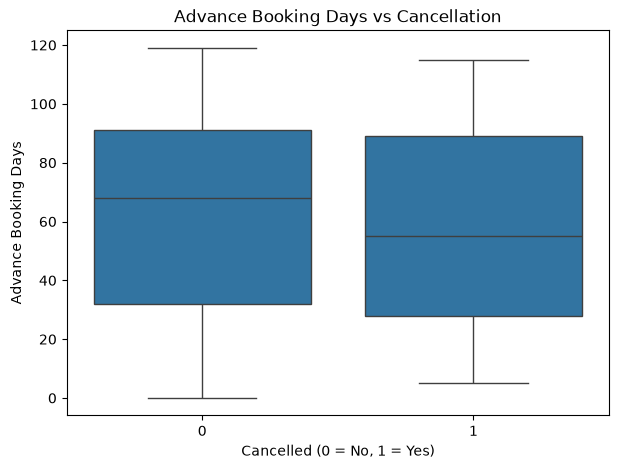

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="cancelled",
    y="advance_booking_days"
)

plt.title("Advance Booking Days vs Cancellation")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Advance Booking Days")

plt.show()

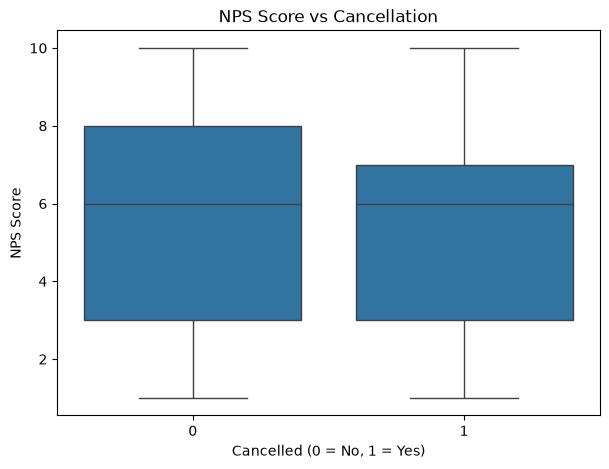

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="cancelled",
    y="nps_score"
)

plt.title("NPS Score vs Cancellation")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("NPS Score")

plt.show()

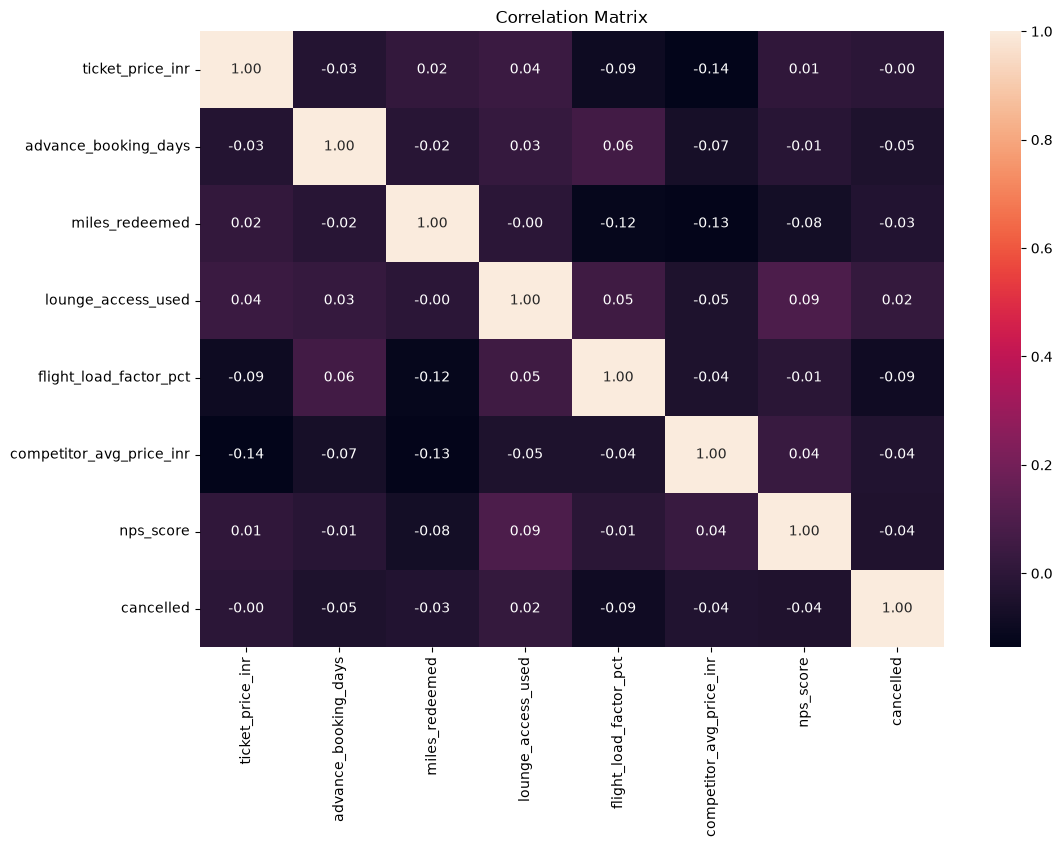

In [19]:
plt.figure(figsize=(12,8))

numeric_data = df.select_dtypes(include=np.number)

correlation = numeric_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [20]:
# Compare numerical variables for cancelled vs non-cancelled bookings

comparison = df.groupby("cancelled")[
    [
        "ticket_price_inr",
        "advance_booking_days",
        "miles_redeemed",
        "flight_load_factor_pct",
        "competitor_avg_price_inr",
        "nps_score"
    ]
].mean()

comparison.index = ["Not Cancelled", "Cancelled"]

display(comparison)

,ticket_price_inr,advance_booking_days,miles_redeemed,flight_load_factor_pct,competitor_avg_price_inr,nps_score
Not Cancelled,18276.920949,63.000000,23829.976285,0.779763,46589.913934,5.731225
Cancelled,17969.378378,58.081081,22475.378378,0.745946,43960.162162,5.378378


In [21]:
correlation_with_cancellation = (
    df.select_dtypes(include=np.number)
      .corr()["cancelled"]
      .sort_values(ascending=False)
)

display(correlation_with_cancellation)

cancelled                   1.000000
lounge_access_used          0.020099
ticket_price_inr           -0.004555
miles_redeemed             -0.031017
competitor_avg_price_inr   -0.035022
nps_score                  -0.040647
advance_booking_days       -0.046755
flight_load_factor_pct     -0.089237
Name: cancelled, dtype: float64

In [23]:
%pip install scipy

   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.4 MB 7.0 MB/s eta 0:00:06
   - -------------------------------------- 1.8/37.4 MB 5.8 MB/s eta 0:00:07
   --- ------------------------------------ 3.7/37.4 MB 6.7 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/37.4 MB 6.8 MB/s eta 0:00:05
   ------- -------------------------------- 6.6/37.4 MB 7.0 MB/s eta 0:00:05
   -------- ------------------------------- 8.4/37.4 MB 7.0 MB/s eta 0:00:05
   ---------- ----------------------------- 9.7/37.4 MB 6.9 MB/s eta 0:00:04
   ----------- ---------------------------- 11.0/37.4 MB 6.9 MB/s eta 0:00:04
   ------------- -------------------------- 12.6/37.4 MB 6.9 MB/s eta 0:00:04
   --------------- ------------------------ 14.2/37.4 MB 7.0 MB/s eta 0:00:04
   ---------------- ----------------------- 15.7/37.4 MB 7.0 MB/s eta 0:00:04
   ------------------ --------------------- 17.3/37.4 MB 7.0 MB/s eta 0:00:03
 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\shaikshahid.ali\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [24]:
from scipy.stats import ttest_ind

In [25]:
cancelled_price = df[df["cancelled"] == 1]["ticket_price_inr"]

not_cancelled_price = df[df["cancelled"] == 0]["ticket_price_inr"]

t_stat, p_value = ttest_ind(
    cancelled_price,
    not_cancelled_price,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.07898850142002994
P-value: 0.9373711426403909


In [26]:
alpha = 0.05

if p_value < alpha:
    print("Result: Statistically significant difference")
else:
    print("Result: No statistically significant difference")

Result: No statistically significant difference
